# Test Lensing models

In [1]:
# including packages
using LazyGrids, PyPlot
using PSFModels

In [2]:
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


# Lens instance

In [3]:
image_para = Dict(
    :num => 50,
    :deltap => 0.09,
    :redshift => 1.0,
    :bkg_noise => 0.5,
    :exp_time => 90,
)

Dict{Symbol, Real} with 5 entries:
  :num       => 50
  :deltap    => 0.09
  :bkg_noise => 0.5
  :redshift  => 1.0
  :exp_time  => 90

In [184]:
x = range(-2, 2, 101)
xg, yg = LazyGrids.ndgrid(x,x)

([-2.0 -2.0 … -2.0 -2.0; -1.96 -1.96 … -1.96 -1.96; … ; 1.96 1.96 … 1.96 1.96; 2.0 2.0 … 2.0 2.0], [-2.0 -1.96 … 1.96 2.0; -2.0 -1.96 … 1.96 2.0; … ; -2.0 -1.96 … 1.96 2.0; -2.0 -1.96 … 1.96 2.0])

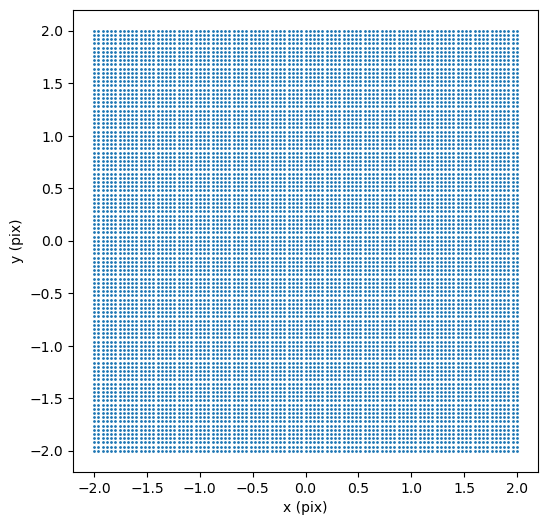

In [185]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(xg, yg, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# SIS

In [7]:
using Jens.LensModel:SIS as SIS

In [8]:
LensParaDict = Dict(:theta_E=>1., :xcentre => 0.1, :ycentre => .2);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIS, LensKwargs=LensParaDict)

([-4.299791333107531 -4.292893218813452 … -4.264644004071198 -4.271800007307197; -4.206891283748216 -4.199928589073943 … -4.171372331097993 -4.178612678969049; … ; 4.221719897266935 4.21463530099501 … 4.185489573506506 4.1928932188134524; 4.314198853502906 4.307173905802272 … 4.27831842547364 4.2856414186248815], [-4.286061751403757 -4.1928932188134524 … 4.222318984144045 4.314635300995009; -4.279166935098144 -4.185927160855422 … 4.215089991232113 4.307468171810287; … ; -4.265196555372512 -4.171800007307198 … 4.2003752073917875 4.292893218813453; -4.272211028207165 -4.178895289712568 … 4.207774816270635 4.300220165183557])

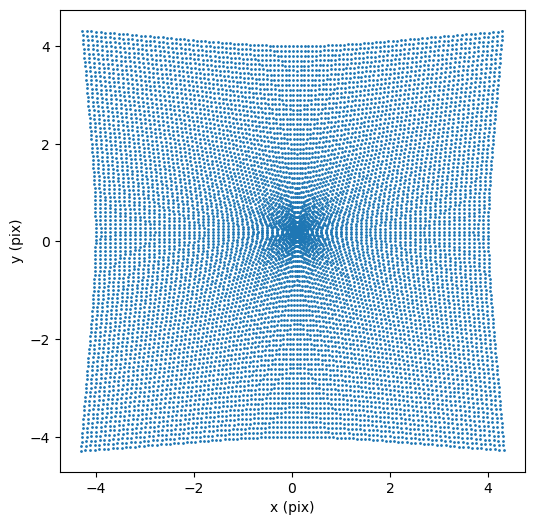

In [9]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [10]:
SIS.LensPotential

LensPotential (generic function with 1 method)

In [11]:
m = SIS.LensPotential(xg, yg; LensParaDict...);

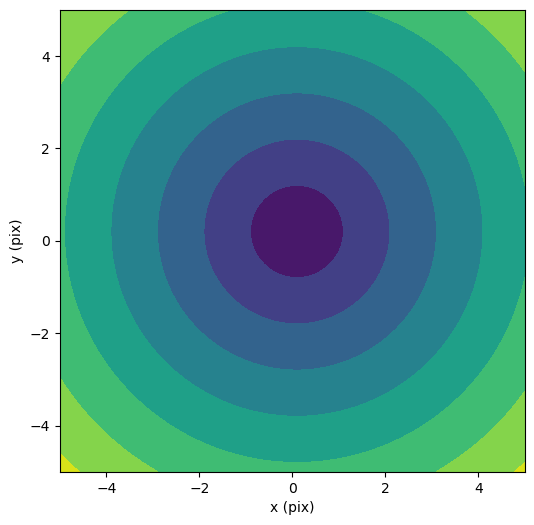

In [12]:
PyPlot.contourf(xg, yg, m)
gcf()

# Shear

In [13]:
using Jens.LensModel:Shear as Shear

In [14]:
LensParaDict = Dict(:gamma1=>0.1, :gamma2=>0.1,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=Shear, LensKwargs=LensParaDict)

([-3.99 -4.0 … -4.98 -4.99; -3.9000000000000004 -3.91 … -4.890000000000001 -4.9; … ; 4.92 4.91 … 3.93 3.9200000000000004; 5.01 5.0 … 4.02 4.01], [-4.99 -4.880000000000001 … 5.9 6.01; -5.0 -4.890000000000001 … 5.890000000000001 6.0; … ; -5.98 -5.870000000000001 … 4.91 5.02; -5.99 -5.880000000000001 … 4.9 5.01])

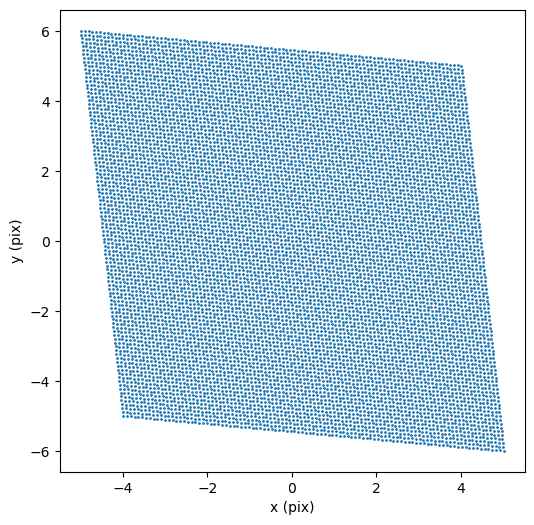

In [15]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Major-axes NIE model

In [42]:
using Jens.LensModel:NIEkappa as NIEkappa

In [249]:
# NIE model 
LensParaDict = Dict(:b => 1.5, :s => 0.1,
 :q => 0.4, :varphi =>  - pi/6. ,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-3.4084429312700584 -3.3978409984042632 … -3.889364210238933 -3.9120760386372533; -3.3192128330532733 -3.3085271570906194 … -3.811922232320483 -3.8346519128492336; … ; 3.88117451145366 3.858461101944717 … 3.3308099902428974 3.341653294184969; 3.957684410395121 3.934954008254963 … 3.419513832272912 3.4302800807040947], [-3.0456637687517105 -2.956881465714677 … 3.2738536673550587 3.350155220102071; -3.035081687818215 -2.9461756994943515 … 3.2509141964693833 3.3276504915773994; … ; -3.282656178148457 -3.2049981866926123 … 2.9245112147950962 3.013683928397703; -3.305145082315224 -3.2279564837411727 … 2.935384526309207 3.024420603551887])

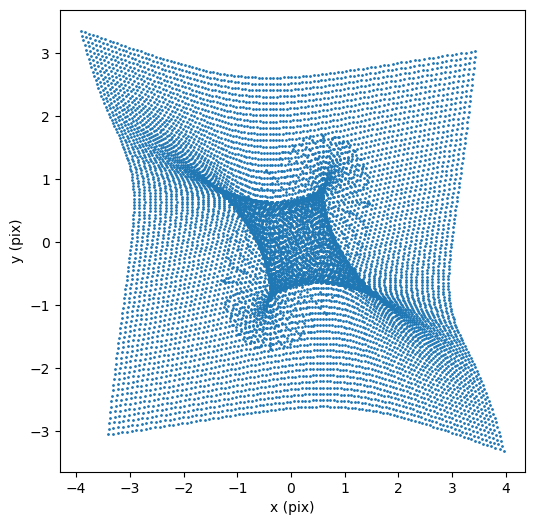

In [250]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [251]:
PyPlot.clf()

In [57]:
# NIE model 1
LensParaDict1 = Dict(:b => 0.6, :s => 0.1,
 :q => 0.2, :varphi =>  - pi/3. ,
  :xcentre => -1.5, :ycentre => 1.);
# NIE model 2
LensParaDict2 = Dict(:b => 0.6, :s => 0.1,
 :q => 0.2, :varphi =>  pi/6. ,
  :xcentre => 2, :ycentre => -1);
betax2, betay2 = LB.MultiLensRayShooting(xg, yg; 
            LensModel = [NIEkappa, NIEkappa],
            LensKwargs = [LensParaDict1, LensParaDict2])

TypeError: TypeError: in keyword argument LensKwargs, expected Vector{Dict{Symbol, Float64}}, got a value of type Vector{Dict{Symbol}}

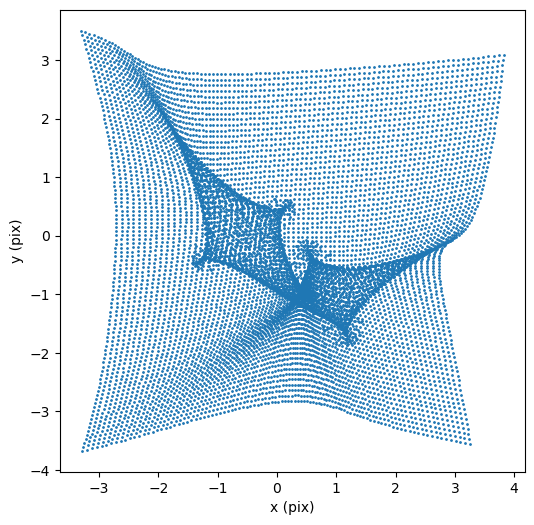

In [45]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [49]:
PyPlot.clf()

## Decouple multiple lenses 2

In [54]:
bx1, by1 = LB.LensPlane(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict1)
bx2, by2 = LB.LensPlane(bx1, by1; LensModel=NIEkappa, LensKwargs=LensParaDict2)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-3.2268867916047235 -3.206348290841537 … -3.29778834652243 -3.3200747810627687; -3.1420849775400637 -3.121080689795282 … -3.22278380422015 -3.245924536417913; … ; 3.2516670757513815 3.2379800906220773 … 3.849998904720504 3.8572721070910707; 3.3332094594808344 3.319647093336995 … 3.933945280648548 3.941411155229063], [-3.7954954082836863 -3.730625013817394 … 3.411133395469478 3.490555129779211; -3.776448619567553 -3.711972269099782 … 3.3888863386322896 3.4680994189473444; … ; -3.495393886746866 -3.4083084864663657 … 2.9420848857643267 3.0349315481967003; -3.5098164017617037 -3.42277241889425 … 2.950117492587039 3.042826013096656])

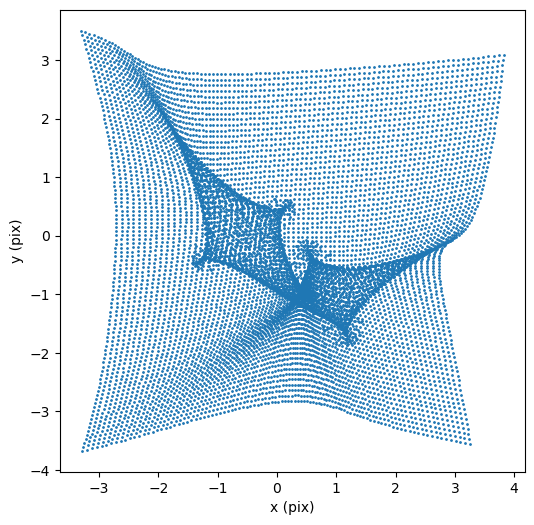

In [55]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [56]:
PyPlot.clf()

# NIE model

In [254]:
using Jens.LensModel:NIE as NIE

In [257]:
# NIE model 
LensParaDict = Dict(:theta_E => 2., :s_scale => 0.1,
 :e1 => 0.2, :e2 =>  0.3,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NIE, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-4.0080420711121745 -3.9902708799997453 … -3.6598332423423923 -3.6694001979032276; -3.9259549946618653 -3.908135598600845 … -3.569653380734747 -3.579292986310315; … ; 3.599892393982574 3.5901168419465326 … 3.9450975429395045 3.9629768916921497; 3.6894545288510483 3.679745286280731 … 4.026409742593342 4.0442653894006195], [-3.5901411134737855 -3.508901598657034 … 3.28418943596343 3.373888376150993; -3.5724956057015893 -3.490954901948052 … 3.274530510977229 3.3643405093661096; … ; -3.3450430598344827 -3.254993592789999 … 3.454926357800522 3.5371101048473754; -3.3547243276821925 -3.2647975278973185 … 3.472959047653689 3.5548145444587274])

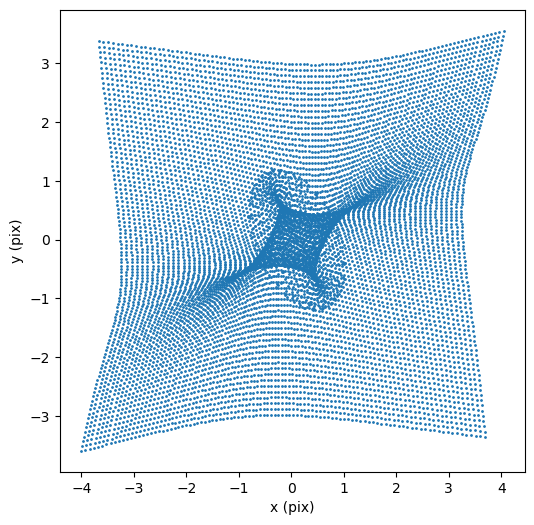

In [258]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Point mass

In [259]:
using Jens.LensModel:PointMass as PointMass

In [260]:
LensParaDict = Dict(:theta_E => 0.3, :xcentre => 0., :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=PointMass, LensKwargs=LensParaDict)

([-4.991 -4.990818200367272 … -4.990818200367272 -4.991; -4.891001836359927 -4.890816326530612 … -4.890816326530612 -4.891001836359927; … ; 4.891001836359927 4.890816326530612 … 4.890816326530612 4.891001836359927; 4.991 4.990818200367272 … 4.990818200367272 4.991], [-4.991 -4.891001836359927 … 4.891001836359927 4.991; -4.990818200367272 -4.890816326530612 … 4.890816326530612 4.990818200367272; … ; -4.990818200367272 -4.890816326530612 … 4.890816326530612 4.990818200367272; -4.991 -4.891001836359927 … 4.891001836359927 4.991])

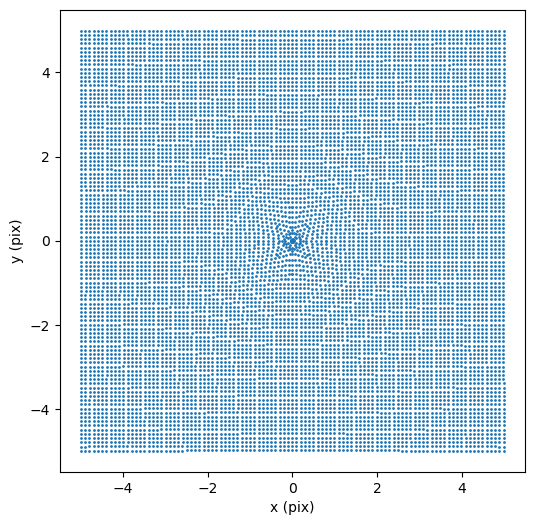

In [261]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# SIE model

In [262]:
using Jens.LensModel:SIE as SIE

In [265]:
LensParaDict = Dict(:b => 2., :s => 0.01,
 :q => 0.6, :varphi =>  0.3,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIE, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-3.5389621445648984 -3.518941405901267 … -3.3174372463710924 -3.332627731496515; -3.458730585478888 -3.4386045260841533 … -3.2323657060018354 -3.2476684492746783; … ; 3.2789902074543336 3.263479312806858 … 3.4794522331784625 3.4997583484590775; 3.3631189171871965 3.347709194977056 … 3.558771338820116 3.5789927671425366], [-3.0376175729535673 -2.9582857825863247 … 2.8207297990438844 2.905038577911608; -3.0176921993921137 -2.9380631449734187 … 2.805386600235077 2.8898880560354243; … ; -2.8592781832442125 -2.77436194520763 … 2.8973055951533535 2.977571556578584; -2.8746327132370766 -2.789928834850549 … 2.9177329962348213 2.9976734060143566])

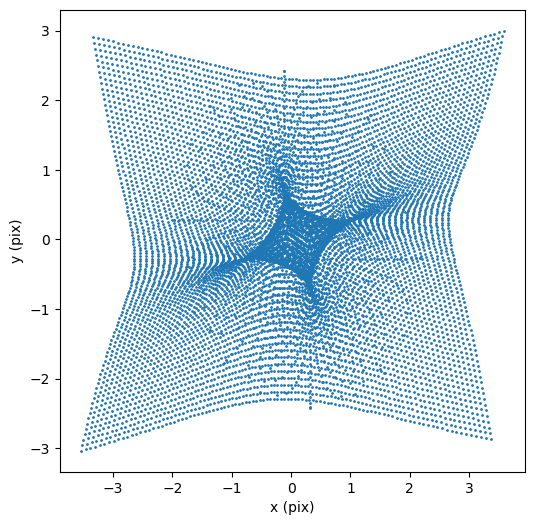

In [266]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# EPL model

In [267]:
using Jens.LensModel:EPL as EPL

In [270]:
LensParaDict = Dict(:theta_E => 1., :gamma => 0.1,
:e1 => 0.1, :e2 =>  0.2,
  :xcentre => 0.1, :ycentre => .1);
betax, betay = LB.LensPlane(xg, yg; LensModel=EPL, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()

([19.45520282384194 19.009620990064796 … 0.5601712043943543 0.34992657528593174; 19.097608492650423 18.652170830466282 … 0.26056330490658386 0.049448934537378975; … ; 1.1737145075534317 0.9507549523553829 … -16.89446865686415 -17.323993964565936; 0.8836127576101385 0.6617214309012924 … -17.2355785014991 -17.665248581012637], [2.3518793663420716 1.8361407346431617 … -57.63505374073716 -58.87953697810125; 2.697644393096283 2.1804041172072397 … -56.568624182501054 -57.805105584003904; … ; 58.38114225471757 57.127531663455855 … -1.6519924562873092 -2.147221032541207; 59.448699002174834 58.187117753767794 … -1.320051009556452 -1.813771882247778])

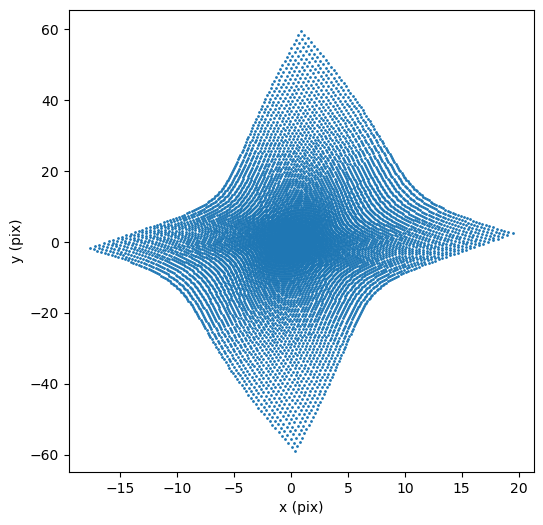

In [271]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# NFW (spherical)

In [138]:
using Jens.LensModel:NFW as NFW

In [139]:
LensParaDict = Dict(:Rs=>2.0, :alpha_Rs=>0.5,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NFW, LensKwargs=LensParaDict)

([-3.6695393878736384 -3.6655520332697042 … -3.6655520332697042 -3.6695393878736384; -3.5919776256526883 -3.587947676468095 … -3.587947676468095 -3.5919776256526883; … ; 3.5986046427479557 3.5944741838826872 … 3.5944741838826872 3.5986046427479557; 3.6758603577471134 3.6717689728622602 … 3.6717689728622602 3.6758603577471134], [-3.67759940280355 -3.6002351147359124 … 3.6002351147359124 3.67759940280355; -3.673609577763869 -3.5962076845161524 … 3.5962076845161524 3.673609577763869; … ; -3.6634603588983827 -3.585952565659721 … 3.585952565659721 3.6634603588983827; -3.6675490848688344 -3.5900857368256567 … 3.5900857368256567 3.6675490848688344])

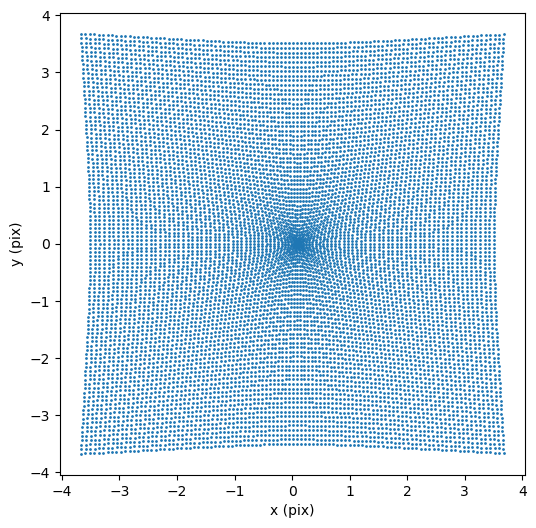

In [140]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# NFW (elliptical)

In [141]:
using Jens.LensModel:NFWE as NFWE

In [142]:
LensParaDict = Dict(:Rs=>1.5, :alpha_Rs=>1., :e1=>0.3, :e2=>0.2,
  :xcentre => 0.4, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NFWE, LensKwargs=LensParaDict)

([-3.5905093310293212 -3.5783496924045575 … -3.579505762950902 -3.5855005965638673; -3.5193396909504333 -3.50727070720582 … -3.5020704650327845 -3.508060988811145; … ; 3.537822640591644 3.531986045485789 … 3.6032128646844437 3.6138748717900255; 3.6144842028169357 3.608621945447422 … 3.6731336882332886 3.6839762053109917], [-3.224122943002925 -3.145750132045999 … 3.2696704035700286 3.3504751616258535; -3.218856519766672 -3.1402364432567094 … 3.2658875975828248 3.346757802340686; … ; -3.308708599893709 -3.2271179383674813 … 3.0918279176750456 3.172873451663434; -3.312574241167548 -3.231060906392919 … 3.096055886929073 3.176868255693746])

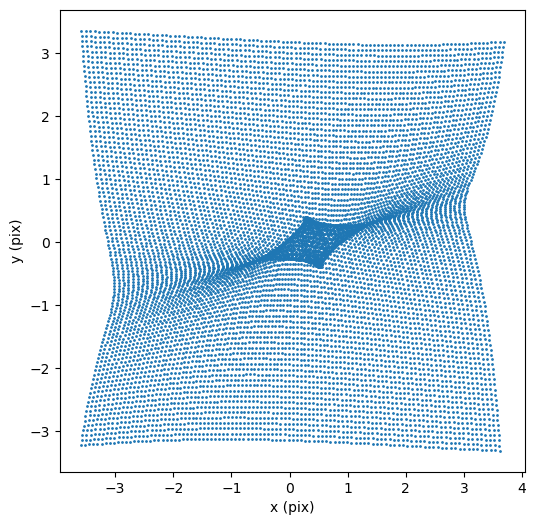

In [143]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Gaussian

In [186]:
using Jens.LensModel:Gaussian as GaussianModel

In [233]:
LensParaDict = Dict(:kappa0=>1.5, :q=>0.5, :sigma=>0.5, :varphi=>0.,
  :xcentre => 0.0, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=GaussianModel, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()

([-1.6648934129856698 -1.6580101958950393 … -1.6580101958950393 -1.6648934129856698; -1.6266927626447631 -1.619752565531782 … -1.619752565531782 -1.6266927626447631; … ; 1.6266927626447631 1.619752565531782 … 1.619752565531782 1.6266927626447631; 1.6648934129856698 1.6580101958950393 … 1.6580101958950393 1.6648934129856698], [-2.3988235920055767 -2.360500241855949 … 2.360500241855949 2.3988235920055767; -2.405647691065065 -2.3675011130088888 … 2.3675011130088888 2.405647691065065; … ; -2.405647691065065 -2.3675011130088888 … 2.3675011130088888 2.405647691065065; -2.3988235920055767 -2.360500241855949 … 2.360500241855949 2.3988235920055767])

Matrix{Float64}(101, 101)Float64()

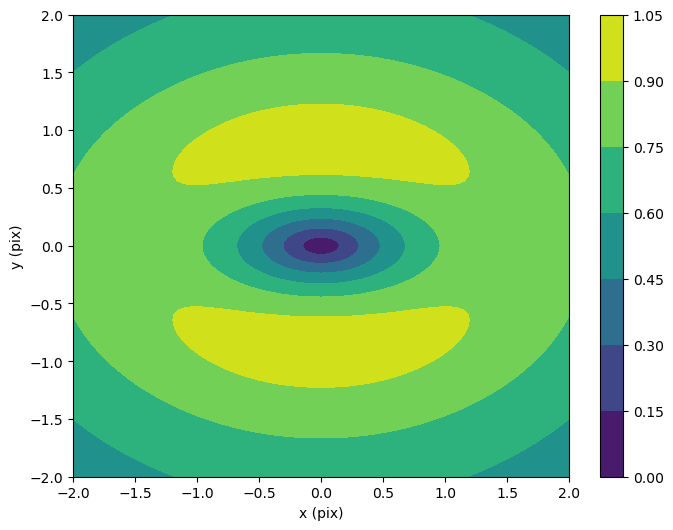

In [234]:
# Gaussian deflection angle
alphax, alphay = GaussianModel.LensDerivative(xg, yg; LensParaDict...)
FigLnes = PyPlot.figure(figsize=(8, 6))
PyPlot.contourf(xg, yg, sqrt.(alphax.^2 .+alphay.^2))
PyPlot.colorbar()
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [235]:
alpha = sqrt.(alphax.^2 .+alphay.^2);
size(alpha[alpha .< 0.01])

(1,)

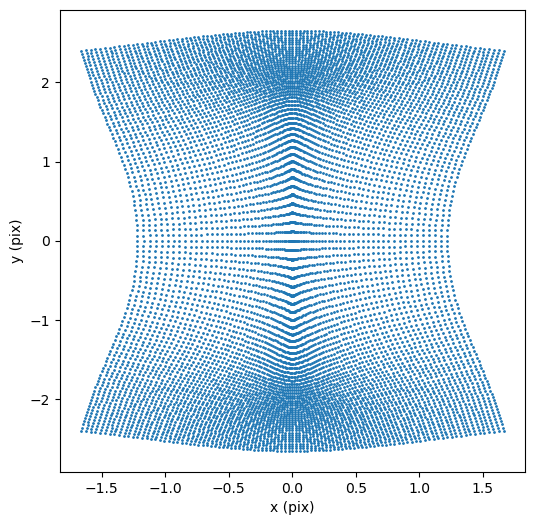

In [236]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [239]:
LensParaDict2 = Dict(:kappa0=>1, :q=>0.3, :sigma=>0.5, :varphi=>pi/4,
  :xcentre => 0., :ycentre => .0);
betax2, betay2 = LB.LensPlane(betax, betay; LensModel=GaussianModel, LensKwargs=LensParaDict2)

Matrix{Float64}(101, 101)Float64()

([-1.1003337919446907 -1.0883262742594906 … -1.7170883364421883 -1.7256753162214418; -1.0658411284123113 -1.0537943867936286 … -1.6831666728489998 -1.691742795350142; … ; 1.691742795350142 1.6831666728489998 … 1.0537943867936286 1.0658411284123113; 1.7256753162214418 1.7170883364421883 … 1.0883262742594906 1.1003337919446907], [-2.6336888996556884 -2.5928182648144347 … 2.8333571575492966 2.8674023124799506; -2.6538985766297483 -2.61382788280027 … 2.8420518623624584 2.8758719484947086; … ; -2.8758719484947086 -2.8420518623624584 … 2.61382788280027 2.6538985766297483; -2.8674023124799506 -2.8333571575492966 … 2.5928182648144347 2.6336888996556884])

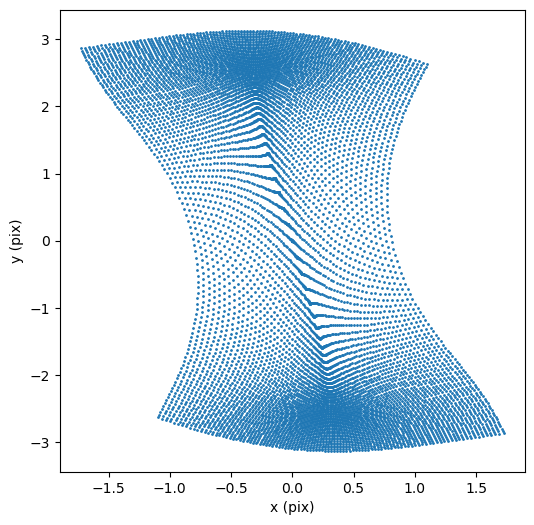

In [240]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [241]:
PyPlot.clf()